<a href="https://colab.research.google.com/github/diabateyoussouf/langgraph-agentic-workflows/blob/main/Projet02_Agent_Recruteur/Projet02_Agent_Recruteur.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
!pip install langchain-community langchain-core langchain-huggingface langchain-mistralai langchain-text-splitters langgraph langchain-chroma chromadb pydantic python-dotenv pypdf

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 52.0/52.0 kB 4.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.4/2.4 MB 19.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 23.3/23.3 MB 73.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 349.5/349.5 kB 23.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 278.2/278.2 kB 22.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 4.6/4.6 MB 101.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.0/1.0 MB 53.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 19.2/19.2 MB 77.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 72.5/72.5 kB 5.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 137.2/137.2 kB 11.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 60.0/60.0 kB 4.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 204.6/204.6 kB 16.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 71.6/7

# Les imports

In [69]:
import os
from typing import TypedDict, Literal,List,Optional

from langchain_community.document_loaders import PyPDFDirectoryLoader,PyPDFLoader
from langchain_text_splitters import RecursiveCharacterTextSplitter
from langchain_huggingface import HuggingFaceEmbeddings
from langchain_community.vectorstores import Chroma
from langchain_mistralai import ChatMistralAI
from langchain_core.messages import HumanMessage, SystemMessage
from langgraph.graph import StateGraph, END
import chromadb
import os
from dotenv import load_dotenv
from pydantic import BaseModel, Field
from langgraph.checkpoint.memory import MemorySaver
from typing_extensions import NotRequired

# SCHÉMAS PYDANTIC

In [70]:
from google.colab import userdata
key = userdata.get('key')

In [71]:
llm = ChatMistralAI(model="mistral-small-latest", temperature=0.0,api_key=key)

In [72]:
class IntentClassification(BaseModel):
    intent: Literal["CV_SUBMISSION", "GENERAL_QA", "POLICY_RISK"] = Field(
        description="CV_SUBMISSION si le candidat soumet son CV/expérience."
    )
    reasoning: str = Field(description="Raison succincte")

In [73]:
class CandidateEvaluation(BaseModel):
    candidate_name: Optional[str] = Field(description="Nom et prénom du candidat. Défaut: 'Candidat'")
    match_score: int = Field(description="Score d'adéquation de 0 à 100")
    matching_skills: List[str] = Field(description="Compétences validées pour le poste")
    missing_skills: List[str] = Field(description="Compétences requises mais absentes du CV")
    recommendation: Literal["INTERVIEW", "HOLD", "REJECT"] = Field(description="Décision finale")
    justification: str = Field(description="Explication neutre et factuelle")

In [74]:
class EvaluationAudit(BaseModel):
    is_fair_and_accurate: Literal["yes", "no"] = Field(
        description="'yes' si l'évaluation reflète fidèlement la présence ou l'absence des compétences requises dans le CV, sinon 'no'."
    )
    reasoning: str = Field(description="Analyse critique du score")

# Modélisation de l'État (RecruiterState)

In [75]:
class RecruiterState(TypedDict):
    messages: List[str]
    job_description: str
    cv_text: Optional[str]
    intent: Optional[str]
    evaluation: Optional[dict]
    eval_valid: Optional[str]
    retry_count: Optional[int]  # Anti-boucle infinie
    final_response: Optional[str]

# NŒUDS

In [76]:
def classify_intent_node(state: RecruiterState) -> dict:
    print("\n🔍 [1] CLASSIFICATION DE L'INTENTION")
    user_message = state["messages"][-1]
    system_prompt = "Tu es un assistant RH. Classifie l'intention de l'utilisateur."
    structured_llm = llm.with_structured_output(IntentClassification)
    res = structured_llm.invoke([
        SystemMessage(content=system_prompt),
        HumanMessage(content=f"Message : {user_message}")
    ])
    print(f"-> Intention : {res.intent}")
    return {"intent": res.intent, "retry_count": 0}

In [77]:
def handle_policy_risk_node(state: RecruiterState) -> dict:
    return {"final_response": "Demande non conforme aux règles RH."}

In [78]:
def handle_general_qa_node(state: RecruiterState) -> dict:
    question = state["messages"][-1]
    jd = state["job_description"]
    res = llm.invoke([SystemMessage(content=f"Réponds selon la fiche : {jd}"), HumanMessage(content=question)])
    return {"final_response": res.content}

In [79]:
def evaluate_candidate_node(state: RecruiterState) -> dict:
    current_retry = state.get("retry_count", 0) + 1
    print(f"\n [2] ÉVALUATION STRUCTURÉE DU CV (Tentative {current_retry})")

    cv = state.get("cv_text") or state["messages"][-1]
    jd = state["job_description"]

    system_prompt = (
        "Tu es un Recruteur Technique Senior. Évalue factuellement l'adéquation du CV "
        "avec la fiche de poste. Si le profil n'a aucun rapport avec le poste, attribue 0/100 et REJECT."
    )
    structured_llm = llm.with_structured_output(CandidateEvaluation)
    eval_res: CandidateEvaluation = structured_llm.invoke([
        SystemMessage(content=system_prompt),
        HumanMessage(content=f"FICHE DE POSTE :\n{jd}\n\nCV CANDIDAT :\n{cv}")
    ])

    print(f"-> Candidat : {eval_res.candidate_name} | Score : {eval_res.match_score}/100 | Décision : {eval_res.recommendation}")
    return {"evaluation": eval_res.model_dump(), "retry_count": current_retry}

In [80]:
def audit_evaluation_node(state: RecruiterState) -> dict:
    print("\n [3] AUDIT ANTI-BIAIS & ANTI-HALLUCINATION")
    evaluation = state["evaluation"]
    cv = state.get("cv_text") or state["messages"][-1]

    # Prompt Clarifié pour l'Audit
    system_prompt = (
        "Tu es un auditeur RH.\n"
        "RÈGLE D'OR : Si le CV ne contient PAS les compétences requises par la Fiche de Poste "
        "(ex: profil administratif pour un poste de développeur), "
        "un score de 0/100 et un REJECT est TOTALEMENT JUSTE ET VALIDE ('yes'). "
        "Ce n'est pas un biais, c'est une inadéquation factuelle."
    )
    structured_llm = llm.with_structured_output(EvaluationAudit)
    audit: EvaluationAudit = structured_llm.invoke([
        SystemMessage(content=system_prompt),
        HumanMessage(content=f"CV :\n{cv}\n\nÉvaluation :\n{evaluation}")
    ])
    print(f"-> Évaluation valide : {audit.is_fair_and_accurate} | Raison : {audit.reasoning[:100]}...")
    return {"eval_valid": audit.is_fair_and_accurate}

In [81]:
def generate_feedback_node(state: RecruiterState) -> dict:
    print("\n✉️ [4] GÉNÉRATION DU FEEDBACK FINAL")
    eval_data = state["evaluation"]
    name = eval_data.get("candidate_name") or "Candidat(e)"
    score = eval_data["match_score"]
    reco = eval_data["recommendation"]
    matches = ", ".join(eval_data["matching_skills"]) if eval_data["matching_skills"] else "Aucune"
    missing = ", ".join(eval_data["missing_skills"]) if eval_data["missing_skills"] else "Compétences clés du poste"

    if reco == "INTERVIEW":
        response = (
            f"🎉 **Toutes nos félicitations, {name} !**\n\n"
            f"Votre profil correspond parfaitement au poste (Score: {score}/100).\n"
            f"**Points forts :** {matches}.\n\n"
            "Nous vous invitons à un entretien !"
        )
    else:
        response = (
            f"Bonjour {name},\n\n"
            f"Merci pour votre candidature. Après étude de votre profil (Score: {score}/100), "
            f"il apparaît que votre profil ne correspond pas aux prérequis techniques du poste (Manquants : {missing}).\n\n"
            "Nous conservons votre profil pour de futures opportunités plus adaptées à vos compétences."
        )
    return {"final_response": response}

# ROUTEURS

In [82]:
def route_intent(state: RecruiterState) -> str:
    intent = state.get("intent")
    if intent == "POLICY_RISK":
        return "handle_policy_risk"
    elif intent == "GENERAL_QA":
        return "handle_general_qa"
    else:
        return "evaluate_candidate"

In [83]:
def route_audit(state: RecruiterState) -> str:
    # Si l'audit est 'yes' OU si on a déjà essayé 2 fois, ON FORME LA SORTIE !
    if state.get("eval_valid") == "yes" or state.get("retry_count", 0) >= 2:
        return "generate_feedback"
    print("⚠️ Audit échoué. Ré-évaluation en cours...")
    return "evaluate_candidate"

# CONSTRUCTION DU GRAPHE

In [84]:
builder = StateGraph(RecruiterState)

builder.add_node("classify_intent", classify_intent_node)
builder.add_node("handle_policy_risk", handle_policy_risk_node)
builder.add_node("handle_general_qa", handle_general_qa_node)
builder.add_node("evaluate_candidate", evaluate_candidate_node)
builder.add_node("audit_evaluation", audit_evaluation_node)
builder.add_node("generate_feedback", generate_feedback_node)

builder.set_entry_point("classify_intent")

builder.add_conditional_edges("classify_intent", route_intent, {
    "handle_policy_risk": "handle_policy_risk",
    "handle_general_qa": "handle_general_qa",
    "evaluate_candidate": "evaluate_candidate"
})

builder.add_edge("evaluate_candidate", "audit_evaluation")
builder.add_conditional_edges("audit_evaluation", route_audit, {
    "generate_feedback": "generate_feedback",
    "evaluate_candidate": "evaluate_candidate"
})

builder.add_edge("handle_policy_risk", END)
builder.add_edge("handle_general_qa", END)
builder.add_edge("generate_feedback", END)

recruiter_app = builder.compile()
print("✅ Agent Recruteur (Patch Anti-Boucle) compilé avec succès !")

✅ Agent Recruteur (Patch Anti-Boucle) compilé avec succès !


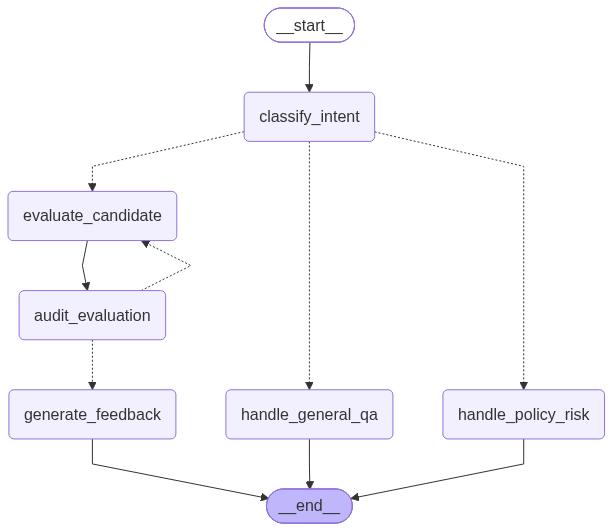

In [85]:
from IPython.display import display, Image
display(Image(recruiter_app.get_graph().draw_mermaid_png()))

In [86]:
import os
from IPython.display import display, Markdown
from langchain_community.document_loaders import PyPDFLoader

def analyser_cv_pdf(pdf_path: str, job_description: str) -> dict:
    """
    Charge un CV au format PDF, l'analyse via l'Agent Recruteur LangGraph
    et affiche le résultat mis en forme.
    """
    # 1. Vérification de l'existence du fichier
    if not os.path.exists(pdf_path):
        print(f" Fichier introuvable : {pdf_path}")
        return None

    # 2. Extraction du texte du PDF
    print(f" Chargement du fichier : {pdf_path} ...")
    loader = PyPDFLoader(pdf_path)
    pages = loader.load()
    cv_texte = "\n".join([page.page_content for page in pages])

    # 3. Invocation de l'agent LangGraph
    print("🤖 Analyse en cours par l'Agent Recruteur ...\n")
    resultat = recruiter_app.invoke({
        "messages": [cv_texte],
        "job_description": job_description
    })

    # 4. Affichage mis en forme du résultat final dans Colab
    print("\n" + "="*60)
    print("📌 RÉSULTAT DU PROCESSUS DE RECRUTEMENT")
    print("="*60 + "\n")

    display(Markdown(resultat["final_response"]))

    return resultat

In [87]:
JOB_DESC = """
Poste: Développeur AI Engineer (LangGraph / Python)
Exigences:
- 3+ ans d'expérience en Python.
- Maîtrise de LangChain / LangGraph et création d'Agents IA.
- Pydantic v2 et bases de données vectorielles (ChromaDB).
- Anglais technique.
"""

CV_TEST = """
Développeur Python avec 4 ans d'expérience.
Compétences : Python, FastAPI, Pydantic, ChromaDB, Docker.
Projets : Création d'architectures Agentic RAG avec LangGraph et Mistral AI.
Langues : Français (natif), Anglais (professionnel).
"""

state_test = {
    "messages": [CV_TEST],
    "job_description": JOB_DESC,
    "cv_text": CV_TEST
}

result = recruiter_app.invoke(state_test)

print("\n" + "="*50)
print("📌 RÉPONSE DE L'AGENT RECRUTEUR :")
print("="*50)
print(result["final_response"])


🔍 [1] CLASSIFICATION DE L'INTENTION
-> Intention : CV_SUBMISSION

 [2] ÉVALUATION STRUCTURÉE DU CV (Tentative 1)
-> Candidat : Candidat | Score : 90/100 | Décision : INTERVIEW

 [3] AUDIT ANTI-BIAIS & ANTI-HALLUCINATION
-> Évaluation valide : yes | Raison : L'évaluation est fidèle et précise. Le CV du candidat correspond aux exigences de la fiche de poste ...

✉️ [4] GÉNÉRATION DU FEEDBACK FINAL

📌 RÉPONSE DE L'AGENT RECRUTEUR :
🎉 **Toutes nos félicitations, Candidat !**

Votre profil correspond parfaitement au poste (Score: 90/100).
**Points forts :** Python (4 ans d'expérience), Pydantic, ChromaDB (bases de données vectorielles), LangGraph (création d'Agents IA), Anglais (professionnel).

Nous vous invitons à un entretien !


In [88]:
# Chemin de ton fichier PDF dans Colab
FICHIER_PDF = "/content/DIABATÉ SALIMATA – Assistante Administrative.pdf"

# Exécution de la fonction
resultat_salimata = analyser_cv_pdf(
    pdf_path=FICHIER_PDF,
    job_description=JOB_DESC
)

 Chargement du fichier : /content/DIABATÉ SALIMATA – Assistante Administrative.pdf ...
🤖 Analyse en cours par l'Agent Recruteur ...


🔍 [1] CLASSIFICATION DE L'INTENTION
-> Intention : CV_SUBMISSION

 [2] ÉVALUATION STRUCTURÉE DU CV (Tentative 1)
-> Candidat : Diabaté Salimata | Score : 0/100 | Décision : REJECT

 [3] AUDIT ANTI-BIAIS & ANTI-HALLUCINATION
-> Évaluation valide : yes | Raison : L'évaluation est totalement juste et précise. Le CV de Diabaté Salimata est centré sur des compétenc...

✉️ [4] GÉNÉRATION DU FEEDBACK FINAL

📌 RÉSULTAT DU PROCESSUS DE RECRUTEMENT



Bonjour Diabaté Salimata,

Merci pour votre candidature. Après étude de votre profil (Score: 0/100), il apparaît que votre profil ne correspond pas aux prérequis techniques du poste (Manquants : 3+ ans d'expérience en Python, Maîtrise de LangChain / LangGraph et création d'Agents IA, Pydantic v2, Bases de données vectorielles (ChromaDB), Anglais technique).

Nous conservons votre profil pour de futures opportunités plus adaptées à vos compétences.

In [89]:
# Charger le CV depuis le fichier PDF dans Colab
loader = PyPDFLoader("/content/DIABATE YOUSSOUF – Data Scientist & AI Engineer.pdf")
pages = loader.load()
cv_depose = "\n".join([page.page_content for page in pages])

# Lancer l'agent directement avec le texte extrait du PDF
result = recruiter_app.invoke({
    "messages": [cv_depose],
    "job_description": JOB_DESC
})

print(result["final_response"])


🔍 [1] CLASSIFICATION DE L'INTENTION
-> Intention : CV_SUBMISSION

 [2] ÉVALUATION STRUCTURÉE DU CV (Tentative 1)
-> Candidat : DIABATE YOUSSOUF | Score : 75/100 | Décision : INTERVIEW

 [3] AUDIT ANTI-BIAIS & ANTI-HALLUCINATION
-> Évaluation valide : yes | Raison : L'évaluation proposée est juste et précise pour les raisons suivantes :

1. **Compétences présentes ...

✉️ [4] GÉNÉRATION DU FEEDBACK FINAL
🎉 **Toutes nos félicitations, DIABATE YOUSSOUF !**

Votre profil correspond parfaitement au poste (Score: 75/100).
**Points forts :** Python, IA Générative (LLM, RAG), Agents IA, NLP, LangChain, Bases de données vectorielles (mentionnées via LlamaIndex et RAG Multimodal).

Nous vous invitons à un entretien !


In [90]:
# Charger le CV depuis le fichier PDF dans Colab
loader = PyPDFLoader("/content/DIABATE YOUSSOUF – Data Scientist.pdf")
pages = loader.load()
cv_depose = "\n".join([page.page_content for page in pages])

# Lancer l'agent directement avec le texte extrait du PDF
result = recruiter_app.invoke({
    "messages": [cv_depose],
    "job_description": JOB_DESC
})

print(result["final_response"])


🔍 [1] CLASSIFICATION DE L'INTENTION
-> Intention : CV_SUBMISSION

 [2] ÉVALUATION STRUCTURÉE DU CV (Tentative 1)
-> Candidat : Diabate Youssouf | Score : 60/100 | Décision : HOLD

 [3] AUDIT ANTI-BIAIS & ANTI-HALLUCINATION
-> Évaluation valide : no | Raison : L'évaluation ne reflète pas fidèlement l'adéquation du CV avec les compétences requises pour un post...
⚠️ Audit échoué. Ré-évaluation en cours...

 [2] ÉVALUATION STRUCTURÉE DU CV (Tentative 2)
-> Candidat : Diabate Youssouf | Score : 60/100 | Décision : HOLD

 [3] AUDIT ANTI-BIAIS & ANTI-HALLUCINATION
-> Évaluation valide : no | Raison : L'évaluation ne reflète pas fidèlement l'adéquation du CV avec les compétences requises pour un post...

✉️ [4] GÉNÉRATION DU FEEDBACK FINAL
Bonjour Diabate Youssouf,

Merci pour votre candidature. Après étude de votre profil (Score: 60/100), il apparaît que votre profil ne correspond pas aux prérequis techniques du poste (Manquants : Maîtrise spécifique de LangGraph (non mentionné dans le CV),

In [91]:
# Charger le CV depuis le fichier PDF dans Colab
loader = PyPDFLoader("/content/DIABATÉ SALIMATA – Assistante Administrative.pdf")
pages = loader.load()
cv_depose = "\n".join([page.page_content for page in pages])

# Lancer l'agent directement avec le texte extrait du PDF
result = recruiter_app.invoke({
    "messages": [cv_depose],
    "job_description": JOB_DESC
})

print(result["final_response"])


🔍 [1] CLASSIFICATION DE L'INTENTION
-> Intention : CV_SUBMISSION

 [2] ÉVALUATION STRUCTURÉE DU CV (Tentative 1)
-> Candidat : Diabaté Salimata | Score : 0/100 | Décision : REJECT

 [3] AUDIT ANTI-BIAIS & ANTI-HALLUCINATION
-> Évaluation valide : yes | Raison : L'évaluation est totalement juste et précise. Le CV de Diabaté Salimata ne contient aucune des compé...

✉️ [4] GÉNÉRATION DU FEEDBACK FINAL
Bonjour Diabaté Salimata,

Merci pour votre candidature. Après étude de votre profil (Score: 0/100), il apparaît que votre profil ne correspond pas aux prérequis techniques du poste (Manquants : 3+ ans d'expérience en Python, Maîtrise de LangChain / LangGraph et création d'Agents IA, Pydantic v2, Bases de données vectorielles (ChromaDB), Anglais technique).

Nous conservons votre profil pour de futures opportunités plus adaptées à vos compétences.
